In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy import integrate

In [2]:
# Define global constants
R = 287 # J / (kg K)
H = 7000 # m 
L = 1100 * 1000 # m 
We = 7.29e-5
a = 6.37e6
Cp = 1005
g = 9.81
dTdz_strat = 3 # K/m
S0 = 3e-3 + g/Cp

# Define QBO parameters
lat = 0
F = 0.1/24/3600
m = 2*np.pi / 25000
omega = 2 * np.pi / (840 * 3600 * 24)
z0 = 30000
dz = 6000
beta = 2*np.cos(lat)*We/a
C = beta * L * L / 2
B = R * S0 / (H * C * C)

# f = - stuff * dF/dz
f = lambda z, t: -(C*H/R) * F * np.exp(-np.power(z-z0, 2) / (2 * np.power(dz, 2))) * ( 
                                -((z-z0)/np.power(dz, 2)) * np.cos(m*z + omega*t) - m*np.sin(m*z + omega*t))


# Define soln parameters
t=0
dt=10*3600*24 #s 
tt=840*5*3600*24 #s 
ts = np.arange(t, tt+dt, dt)

p = 5000
pp = 50000 + 450
dp = 450
zs = np.arange(p, pp, dp)

z1 = 5000
z2 = 50000

In [11]:
# Define solution

int1_func = lambda u, t: np.sqrt(1/B) * np.sin(np.sqrt(B) * (u-z1)) * f(u, t)
int2_func = lambda u, t: np.sqrt(1/B) * np.cos(np.sqrt(B) * (u-z1)) * f(u, t)

int1 = lambda z, t: integrate.quad(int1_func, z1, z, args=(t,))
int2 = lambda z, t: integrate.quad(int2_func, z1, z, args=(t,))

D = lambda t: int1(z2, t)[0] / np.tan(np.sqrt(B) * (z2 - z1)) - int2(z2, t)[0]

w = lambda z, t: D(t) * np.sin(np.sqrt(B) * (z-z1)) - np.cos(np.sqrt(B) * (z-z1)) * int1(z, t)[0] + np.sin(np.sqrt(B) * (z-z1)) * int2(z, t)[0]

w_soln = np.zeros(shape=(len(ts), len(zs)))

for i in range(len(ts)):
    for j in range(len(zs)):
        w_soln[i, j] = w(zs[j], ts[i])

In [9]:
# Define solution

int_func = lambda u, z, t: np.sqrt(1/B) * np.sin(np.sqrt(B) * (z - u)) * f(u, t)

inte = lambda z, t: integrate.quad(int_func, z1, z, args=(z, t,))

w = lambda z, t: -np.sin(np.sqrt(B)*(z-z1)) * inte(z2, t)[0] / np.sin(np.sqrt(B)*(z2-z1)) + inte(z, t)[0]

w_soln = np.zeros(shape=(len(ts), len(zs)))

for i in range(len(ts)):
    for j in range(len(zs)):
        w_soln[i, j] = w(zs[j], ts[i])

In [9]:
# Define solution

int1_func = lambda u, t: np.cos(np.sqrt(B)*(u - z0)) * curly_F(u, t)
int2_func = lambda u, t: np.cos(np.sqrt(B)*(z1 - u)) * curly_F(u, t)

int1 = lambda z, t: integrate.quad(int1_func, z0, z, args=(t,))
int2 = lambda z, t: integrate.quad(int2_func, z, z1, args=(t,))

w = lambda z, t: (C * H / (R * np.sin(np.sqrt(B) * (z1 - z0)))) * (
    -np.sin(np.sqrt(B)*(z1-z))*int1(z, t)[0] + np.sin(np.sqrt(B)*(z-z0))*int2(z, t)[0]
)


w_soln = np.zeros(shape=(len(ts), len(zs)))

for i in range(len(ts)):
    for j in range(len(zs)):
        w_soln[i, j] = w(zs[j], ts[i])

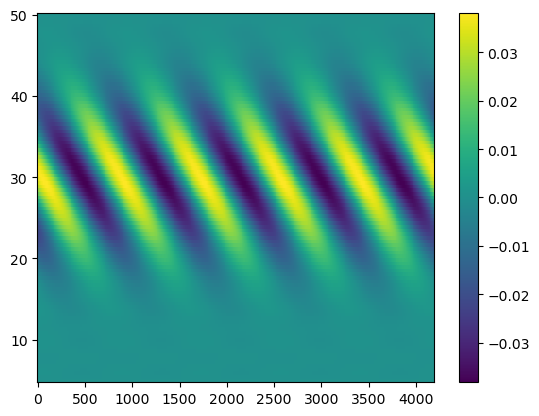

In [12]:
fig = plt.figure()

T, Z = np.meshgrid(ts, zs)

plt.pcolormesh(T/3600/24, Z/1000, w_soln.T)
plt.colorbar()

np.save('analytic_soln2.npy', w_soln)